Given the dataset ‘data_3_1_1.csv’, build a logistic
regression model with the hypothesis h(x) = g(theta_0 + theta_1 * x_1 + theta_2 * x_2)

In [3]:
import numpy as np
import pandas as pd

# Load data
data = pd.read_csv('/home/tikea/ecam_ws/ecam_courses/machine_learning/data_3_1_1.csv').to_numpy()

x1 = data[:, 0] # all the rows, first column
x2 = data[:, 1]
# we can also do x = data[:, :-1] to get all the columns except the last one
y = data[:, 2]

print("x1", x1.shape)
print("x2", x2.shape)
print("y", y.shape)
print("x1_mean", x1.mean())
print("x1_std", x1.std())
print("x2_mean", x2.mean())
print("x2_std", x2.std())

x1 (100,)
x2 (100,)
y (100,)
x1_mean 4.8598
x1_std 2.0577599374076656
x2_mean 6.0577
x2_std 1.451782941765056


![alt text](image.png)

x_scaled = (x - mu) / sigma

In [8]:
# Feature scaling 
# This is the standard normal distribution, which has a mean of 0 and a standard deviation of 1.

x1_scaled = (x1 - x1.mean()) / x1.std()
x2_scaled = (x2 - x2.mean()) / x2.std()

print(x1_scaled.mean(), x1_scaled.std())
print(x2_scaled.mean(), x2_scaled.std())

3.9968028886505634e-17 1.0
2.353672812205332e-16 0.9999999999999999


In [11]:
import torch

# convert to torch tensors
tx1 = torch.tensor(x1_scaled, dtype=torch.float32)
tx2 = torch.tensor(x2_scaled, dtype=torch.float32)
ty  = torch.tensor(y,         dtype=torch.float32)

In [ ]:
import torch.optim as optim

# initialize all parammeters of the model

a = torch.tensor(0, dtype=torch.float32, requires_grad=True)
b = torch.tensor(0, dtype=torch.float32, requires_grad=True)
c = torch.tensor(0, dtype=torch.float32, requires_grad=True)

opt = optim.SGD([a, b, c], lr=1)

for i in range(100):
    tz = a*tx1 + b*tx2 + c
    tz = torch.sigmoid(tz)

    J = (-ty*torch.log(tz) - (1-ty)*torch.log(1-tz)).mean()

    print('i: %d, Cost: %f' % (i, J.item()))

    J.backward()

    opt.step() #update the parameters
    opt.zero_grad() #reset the gradient of each parameter





In [13]:
#Evaluate the model

tz = a*tx1+b*tx2+c
tz = torch.sigmoid(tz)
predict = (tz>=0.5).float()

acc_rate = (predict == ty).float().mean()
print('Accuracy: %f' % acc_rate)

Accuracy: 0.970000


/home/tikea/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


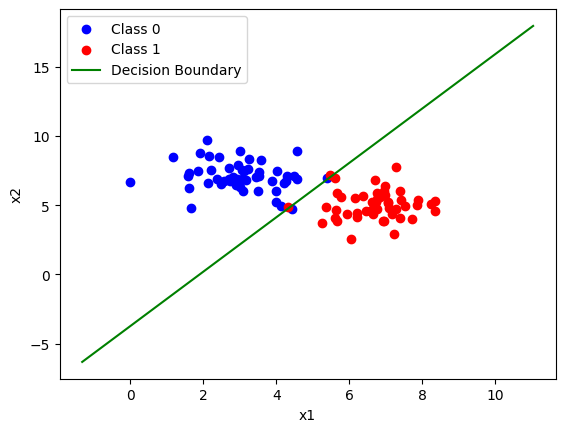

In [14]:
import matplotlib.pyplot as plt

# Plot the data points
plt.scatter(x1[y==0], x2[y==0], color='blue', label='Class 0')
plt.scatter(x1[y==1], x2[y==1], color='red', label='Class 1')

# Plot the decision boundary
# at decision boundary: a*x1_scaled + b*x2_scaled + c = 0
# => x2_scaled = (-a*x1_scaled - c) / b
x1_line = torch.linspace(-3, 3, 100)
x2_line = (-a*x1_line - c) / b

# convert back to original scale
x1_line_orig = x1_line.detach().numpy() * np.std(x1) + np.mean(x1)
x2_line_orig = x2_line.detach().numpy() * np.std(x2) + np.mean(x2)

plt.plot(x1_line_orig, x2_line_orig, color='green', label='Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

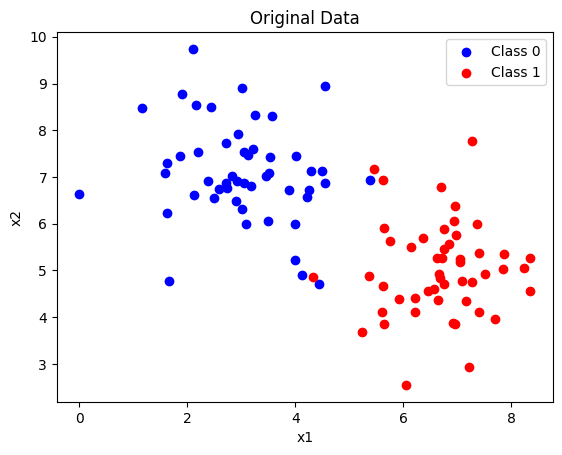

In [15]:
# Plot the data points
plt.scatter(x1[y==0], x2[y==0], color='blue', label='Class 0')
plt.scatter(x1[y==1], x2[y==1], color='red', label='Class 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Original Data')
plt.show()